In [1]:
import importlib.util, subprocess, sys
from pathlib import Path
if importlib.util.find_spec("mimosa") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "mimosa-ml"], check=True)
# On Colab the notebook runs from /content, where the example's data folder does not exist.
from urllib.request import urlretrieve
DATA_URL = "https://raw.githubusercontent.com/SimLej18/mimosa-ml/main/docs/examples/data"
Path("data").mkdir(exist_ok=True)
for name in ("train_swimmers.csv", "test_swimmers.csv"):
    if not Path("data", name).exists():
        urlretrieve(f"{DATA_URL}/{name}", Path("data", name))

# Basic multi-task usage of Mimosa

This example walks through the full pipeline on a *real* dataset -- swimming performances -- loaded from
CSV: configure the dimensions, fit a `BasicModel`, then predict a task and sample from that prediction.

The setting is deliberately kept simple: every swimmer is a task and they all follow a single shared
pattern, so `K=1` (no clustering). There is also a single channel and a single output (`C=1`, `O=1`),
so the only structure Mimosa actually uses is the multi-task sharing.

Written using jupytext's py:percent format. This script can be run cell-by-cell or as a usual Python
script.

## Getting started

First, the usual imports and configs:

In [36]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_disable_jit", False)
import jax.random as jr
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt

from kernax import ConstantMean, VarianceKernel, SEKernel, WhiteNoiseKernel

from mimosa import (
	Dimensions, Dataset, Mixture, ModelConfig, Parameters,
	BasicModel, UnionGrid,
	load_csv, build_parameters, sample_gp,
	plot_dataset, plot_clusters, plot_single_task_prediction,
)

key = jr.PRNGKey(42)
plt.rcParams['figure.dpi']=300

We start by loading the train and test sets. Both files share the same format: one row per observed
point, with a `TaskID`, an input coordinate `Input_1` and a single output `Output1_1`. 

The dataset contains competition records for 1731 French female athletes between 10 and 20 years old in 100m freestyle events. Each swimmer is considered a task, and each row is one of that swimmer's performances at a given age. 

In [3]:
train_data = load_csv("data/train_swimmers.csv")
test_data = load_csv("data/test_swimmers.csv")

Mimosa keeps track of the dimensions of the datasets and the shape of the model parameters via two
objects: `Dimensions` and `ModelConfig`. Here we read most of them straight off the loaded data.

For a *simple multi-task* setting we only need to set:
* `K`, the number of clusters, to 1 -- no clustering, every task shares the same mean-process;
* `O`, the number of correlated outputs, to 1 -- no multi-output;
* `C`, the number of channels, to 1 -- no multi-channel.

`T`, `N` and `I` are read from the loaded dataset. `G` is the number of points on the prediction
grid, which we build later as the union of every swimmer's inputs.

In [4]:
# The fitting grid is the union of every swimmer's input points, and G is its size. Grid
# construction isn't jit-compatible, so it's done here by the caller, outside of fit/predict, rather
# than owned by the model -- see mimosa.grid.GridBuilder.
fitted_grid = UnionGrid()(train_data.inputs)
G = len(fitted_grid.points)

# Dimensions: T tasks, K clusters, I input dims, C channels, O correlated outputs, N points
# observed per task, G points in the full grid.
T, N, C = train_data.outputs.shape
I = train_data.inputs.shape[-1]

dims = Dimensions(T=T, K=1, I=I, C=C, O=1, N=N, G=G)

# ModelConfig controls which hyperparameters are shared (across tasks/clusters/channels/outputs) and
# whether tasks/outputs share input locations. Swimmers are measured on overlapping but not identical
# locations, so isotopic_tasks is False.
model_config = ModelConfig(
	shared_task_hps=True,
	shared_cluster_hps=True,
	shared_channel_hps=True,
	cluster_specific_task_hps=False,
	isotopic_tasks=False,
)
print(f"Dimensions: {dims}")
print(f"Model config: {model_config}")

Dimensions: Dimensions(T=874, K=1, I=1, C=1, O=1, N=55, G=956)
Model config: ModelConfig(shared_task_hps=True, shared_cluster_hps=True, shared_channel_hps=True, cluster_specific_task_hps=False, isotopic_tasks=False, isotopic_output_in_tasks=True, isotopic_output_in_grid=True)


## Exploring the raw dataset

A first broad view of the whole training set, then a single swimmer. Try changing `t_id` below to
look at a different swimmer!

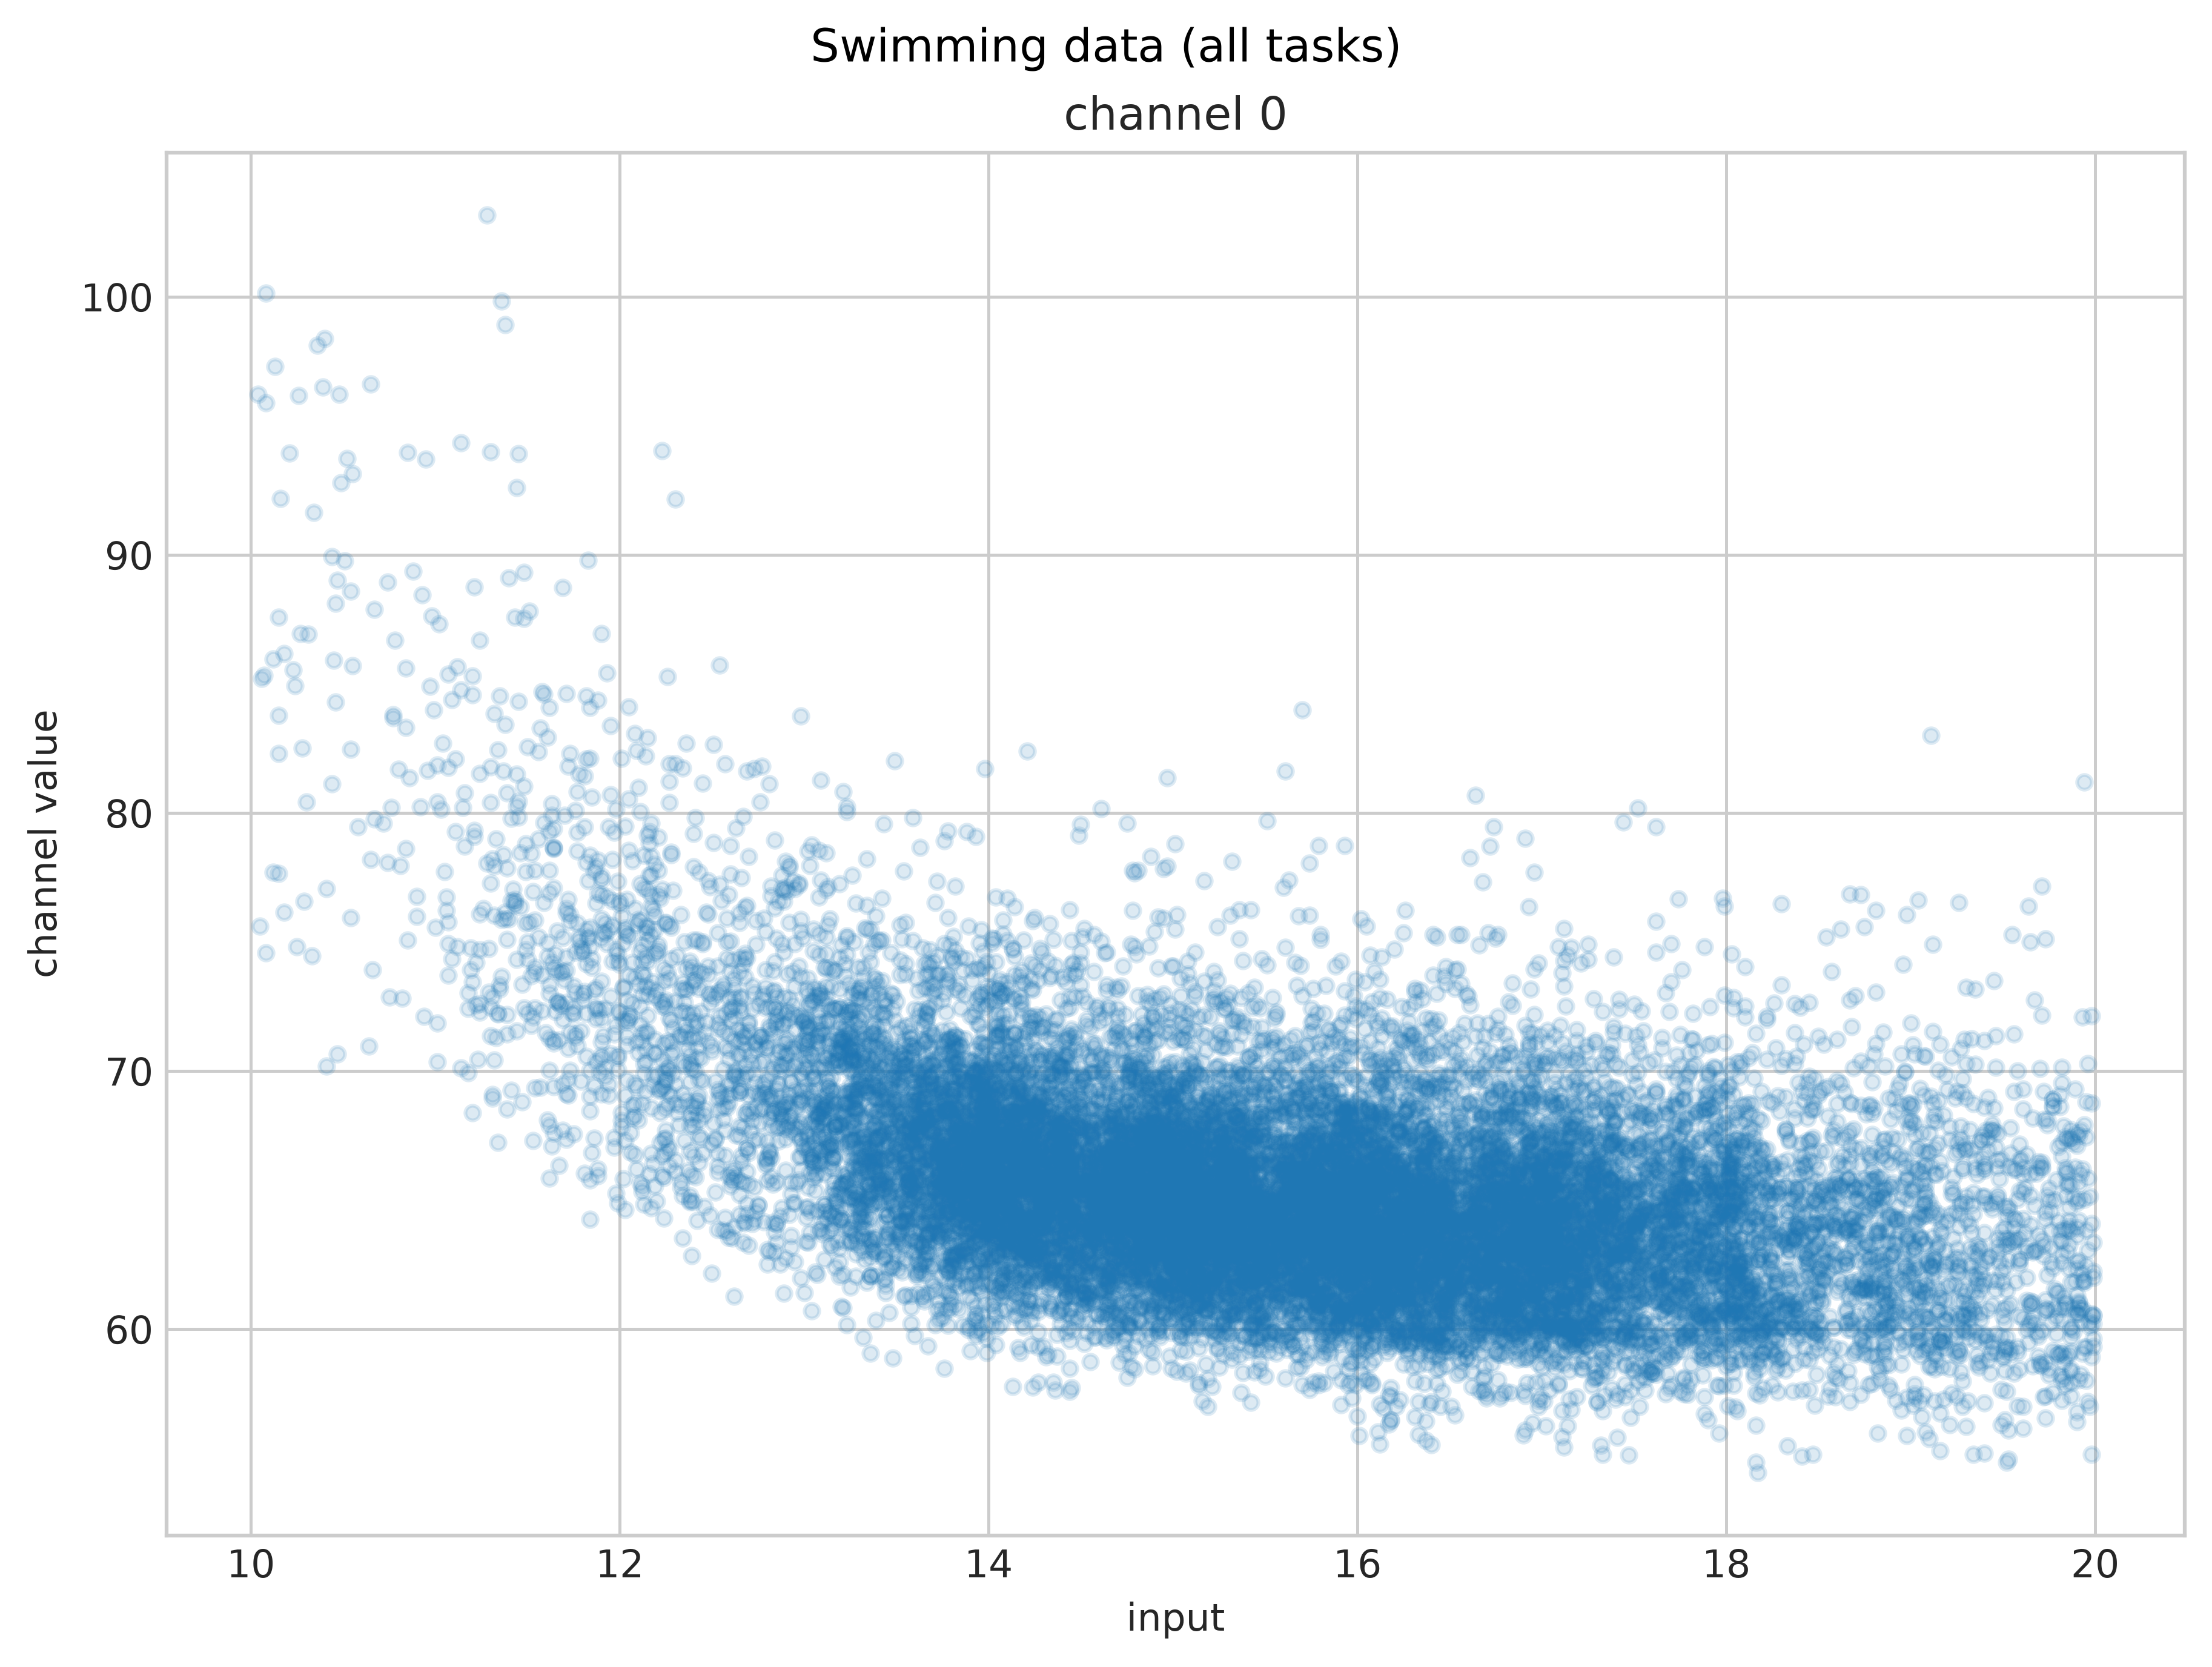

In [5]:
fig, ax = plot_dataset(train_data, dims, figsize=(8 * dims.C, 6), alpha=.15)
fig.suptitle("Swimming data (all tasks)")
plt.show()

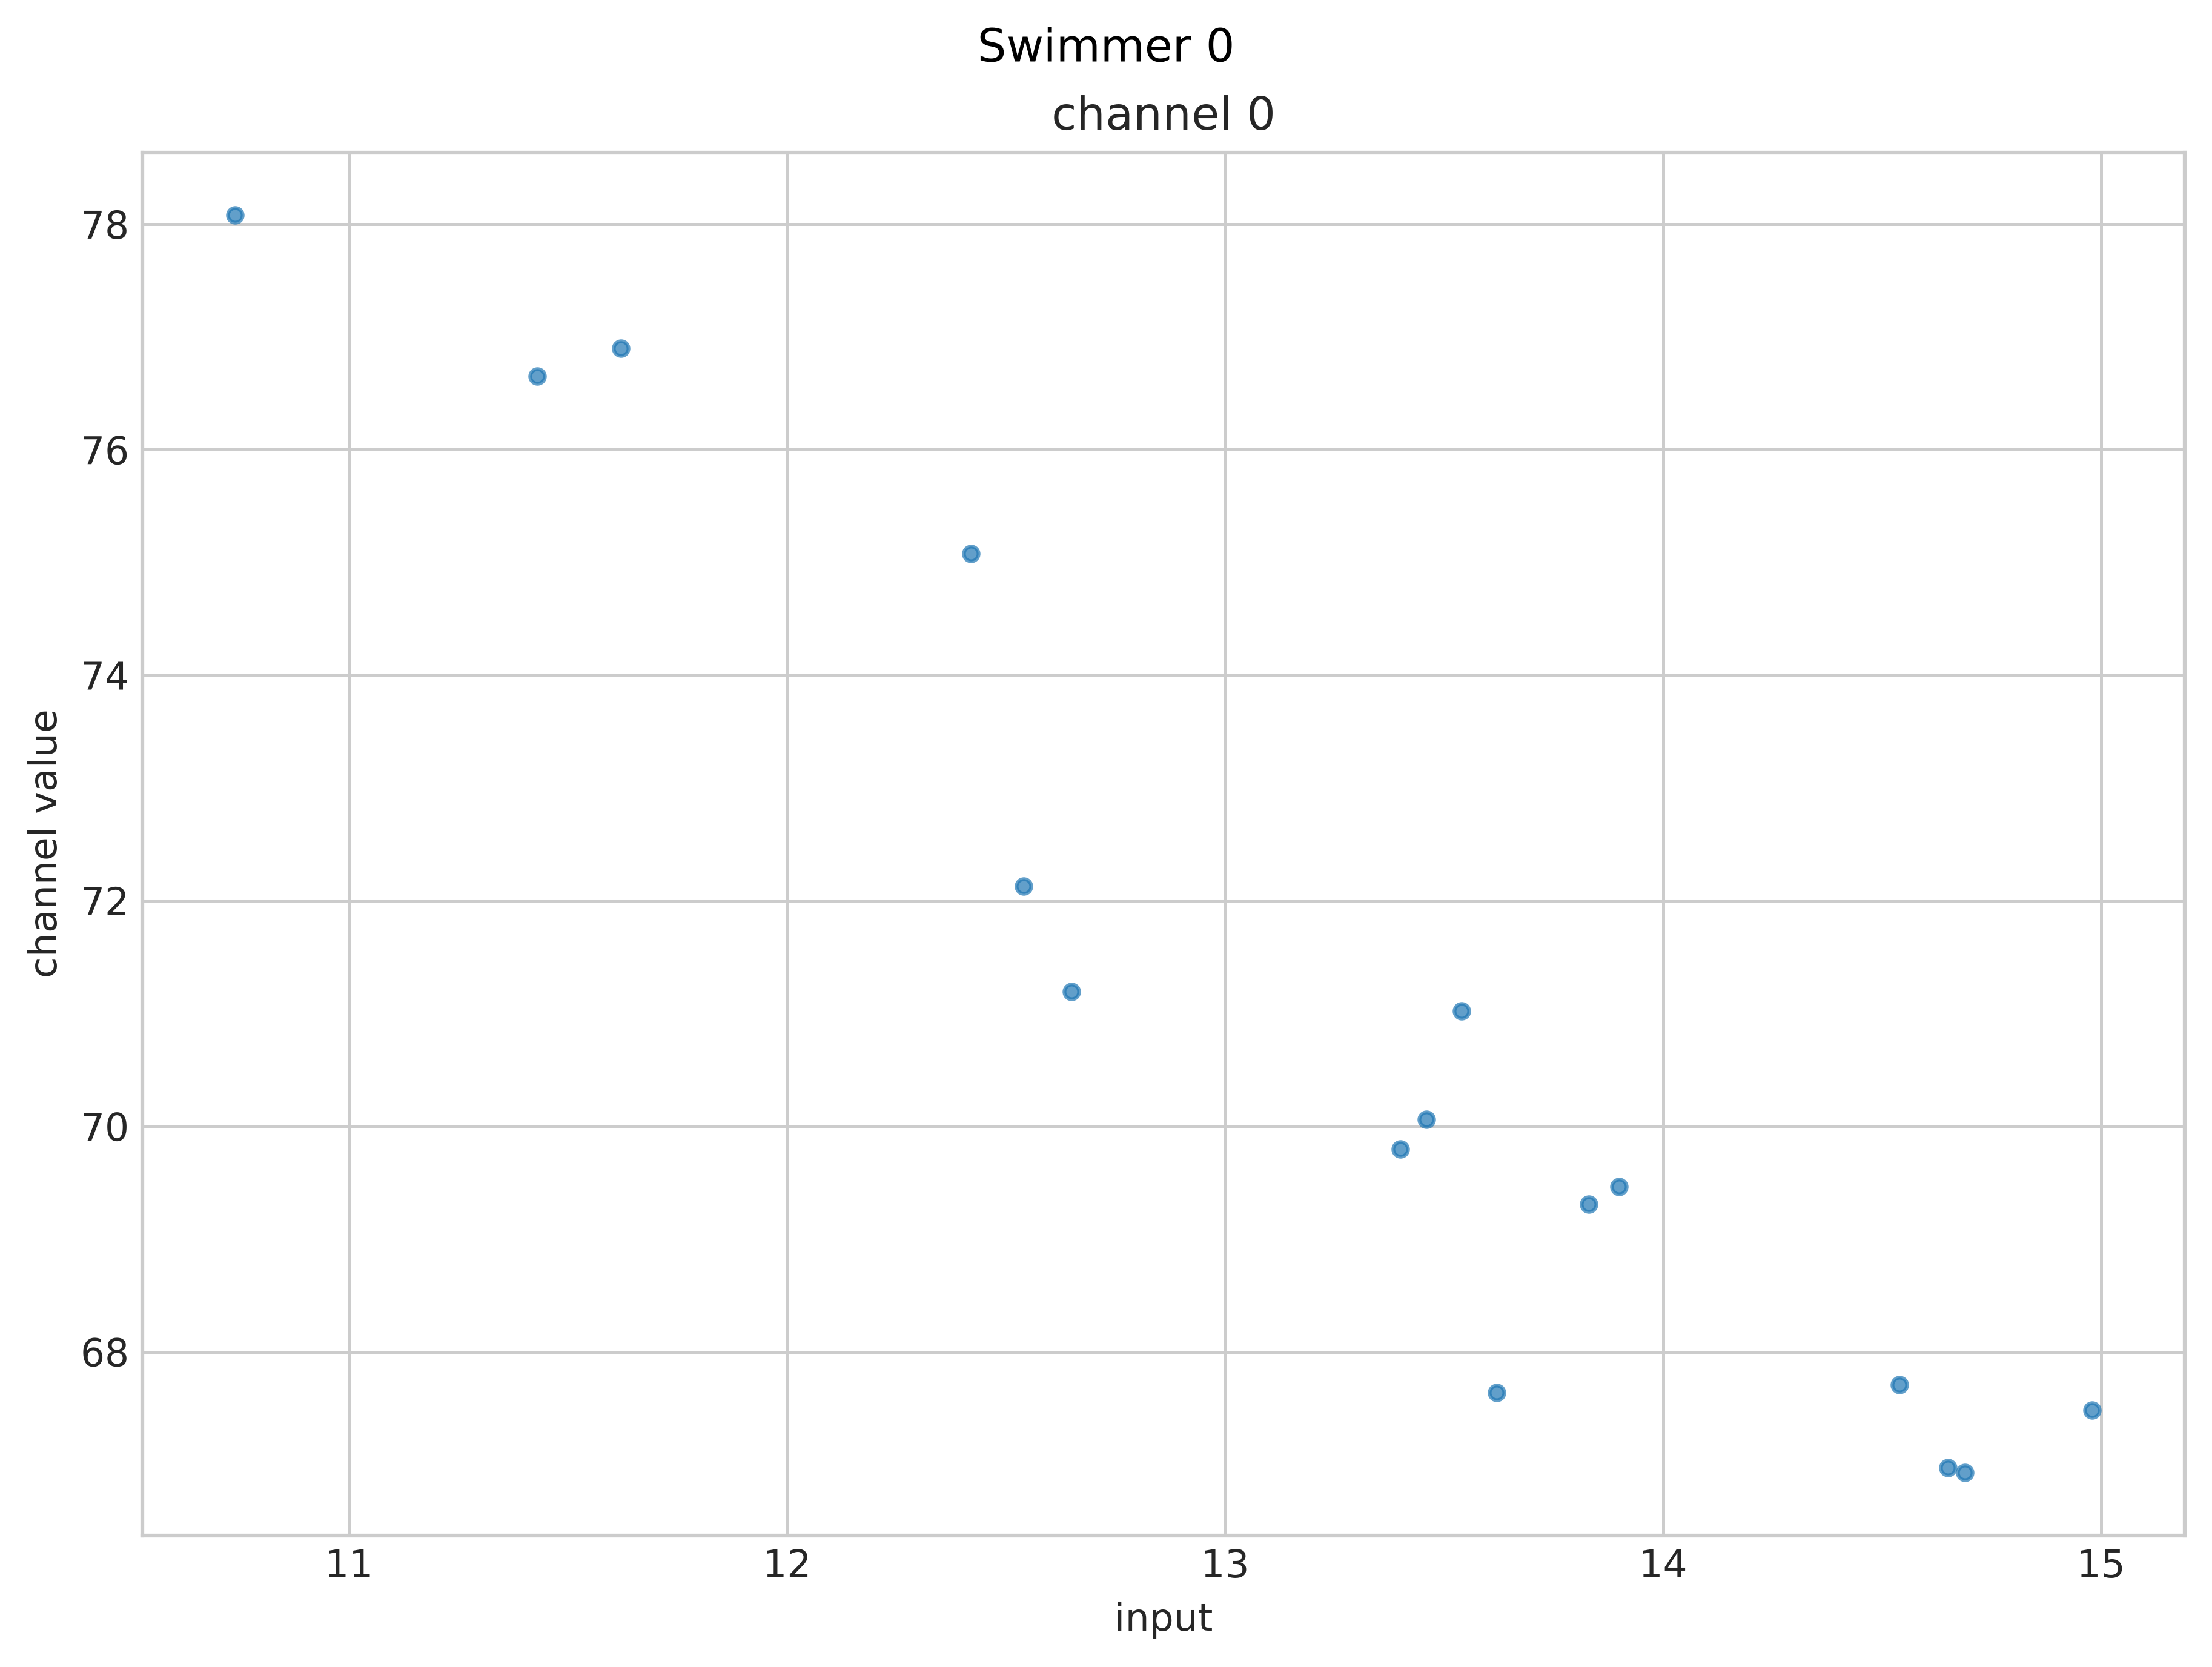

In [12]:
t_id = 0
fig, ax = plot_dataset(train_data, dims, figsize=(8 * dims.C, 6), t_id=t_id)
fig.suptitle(f"Swimmer {t_id}")
plt.show()

## Training the model

A model is described by 4 parameters:
* `cluster_mean`: the mean function of the mean-process, i.e. the long-term pattern every swimmer is
  centered on
* `cluster_kernel`: the kernel of the mean-process, i.e. its "shape" (smooth, wiggly, periodic...)
* `task_kernel`: the kernel of the tasks, i.e. how they vary around their mean-process
* `noise_kernel`: the noise on the observed points

The initial values do not matter too much -- they are optimised during fitting -- but their structure
does, which is what `build_parameters` takes care of. The values below are expressed in the data's
own units: inputs span ~10-20 and outputs sit around ~65.

In [13]:
#  The jitter is the numerical stabiliser added before Cholesky factorizations, only increase it if you hit factorization errors.
key, model_key = jr.split(key)
model = BasicModel(prng_key=model_key, n_clusters= 1)

# Starting guess for the parameters to fit. In practice these would be a rough, uninformed guess.
init_params = Parameters(
		cluster_mean=ConstantMean(65.),
		cluster_kernel=VarianceKernel(5.0) * SEKernel(length_scale=2.),
		task_kernel=VarianceKernel(2.0) * SEKernel(length_scale=1.),
		noise_kernel=WhiteNoiseKernel(noise=1.))

# build_parameters batches the base kernels/mean below to match model_config's sharing structure
# (same helper generate_data uses internally), so their shapes line up with what model.fit expects.
init_params = build_parameters(init_params, dims, model_config)

In [23]:
# The grid was already built and its size stored in `dims.G` (see section 2).
hyperposterior, fitted_mixture, fitted_params = model.fit(train_data, fitted_grid, init_params, n_iter=50)

Training model for 50 iterations:: 100%|██████████| 50/50 [04:48<00:00,  5.77s/it]


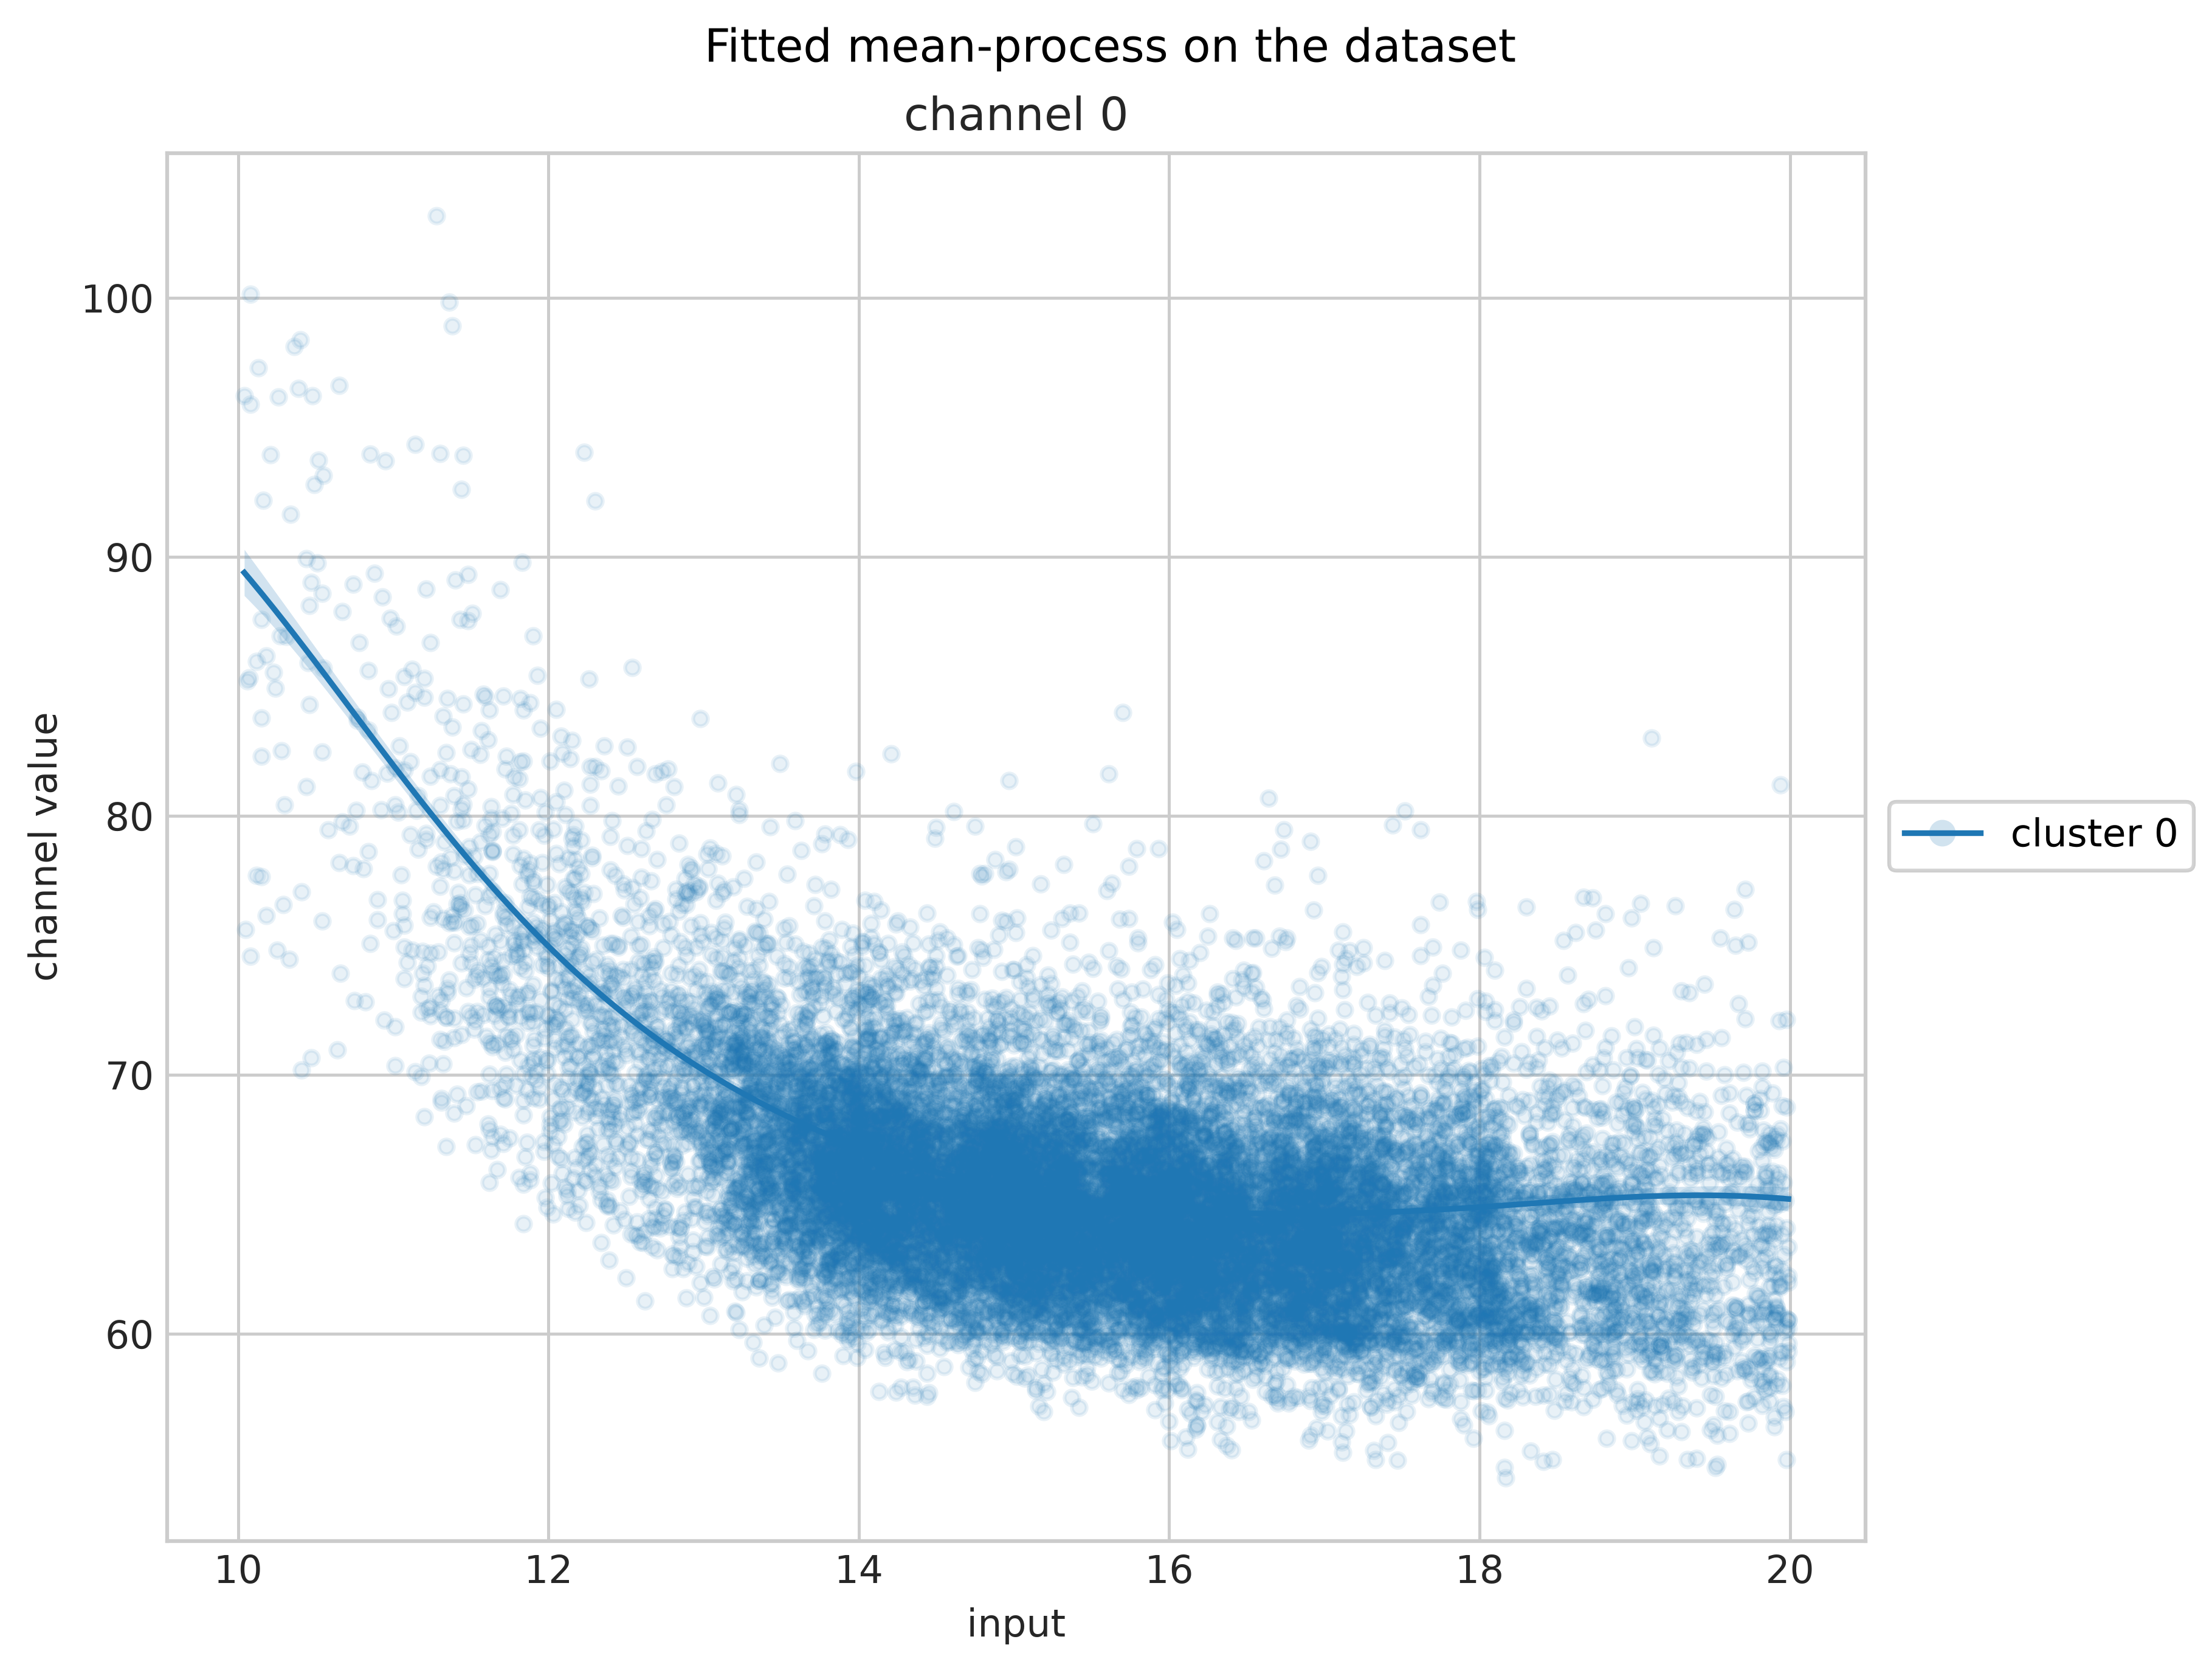

In [15]:
fig, ax = plot_dataset(train_data, dims, mixture=fitted_mixture, figsize=(8 * dims.C, 6), alpha=.1)
fig, ax = plot_clusters(fitted_grid, dims, hyperposterior=hyperposterior, figsize=(8 * dims.C, 6), fig=fig, ax=ax)
fig.suptitle("Fitted mean-process on the dataset")
plt.show()

## Predicting

In a simple multi-task setting, the prediction for a swimmer can be directly accessed with
`predictions[t_id, 0, 0]`. Now that we have trained the model on the training set, we can pick a new, unobserved swimmer from the testing set and leveraged shared information from the mean process to provide more accurate prediction than vanilla GP. 

In [ ]:
predictions = model.predict(train_data, fitted_grid, fitted_mixture, fitted_params)  # MultivariateNormal, batched (T, K, C, O*G)

prediction = predictions[t_id, 0, 0]

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * the `axis_size` argument was 874;
  * one axis had size 857: axis 0 of argument _dynamic_args[1][0] of type float64[857,61,1]

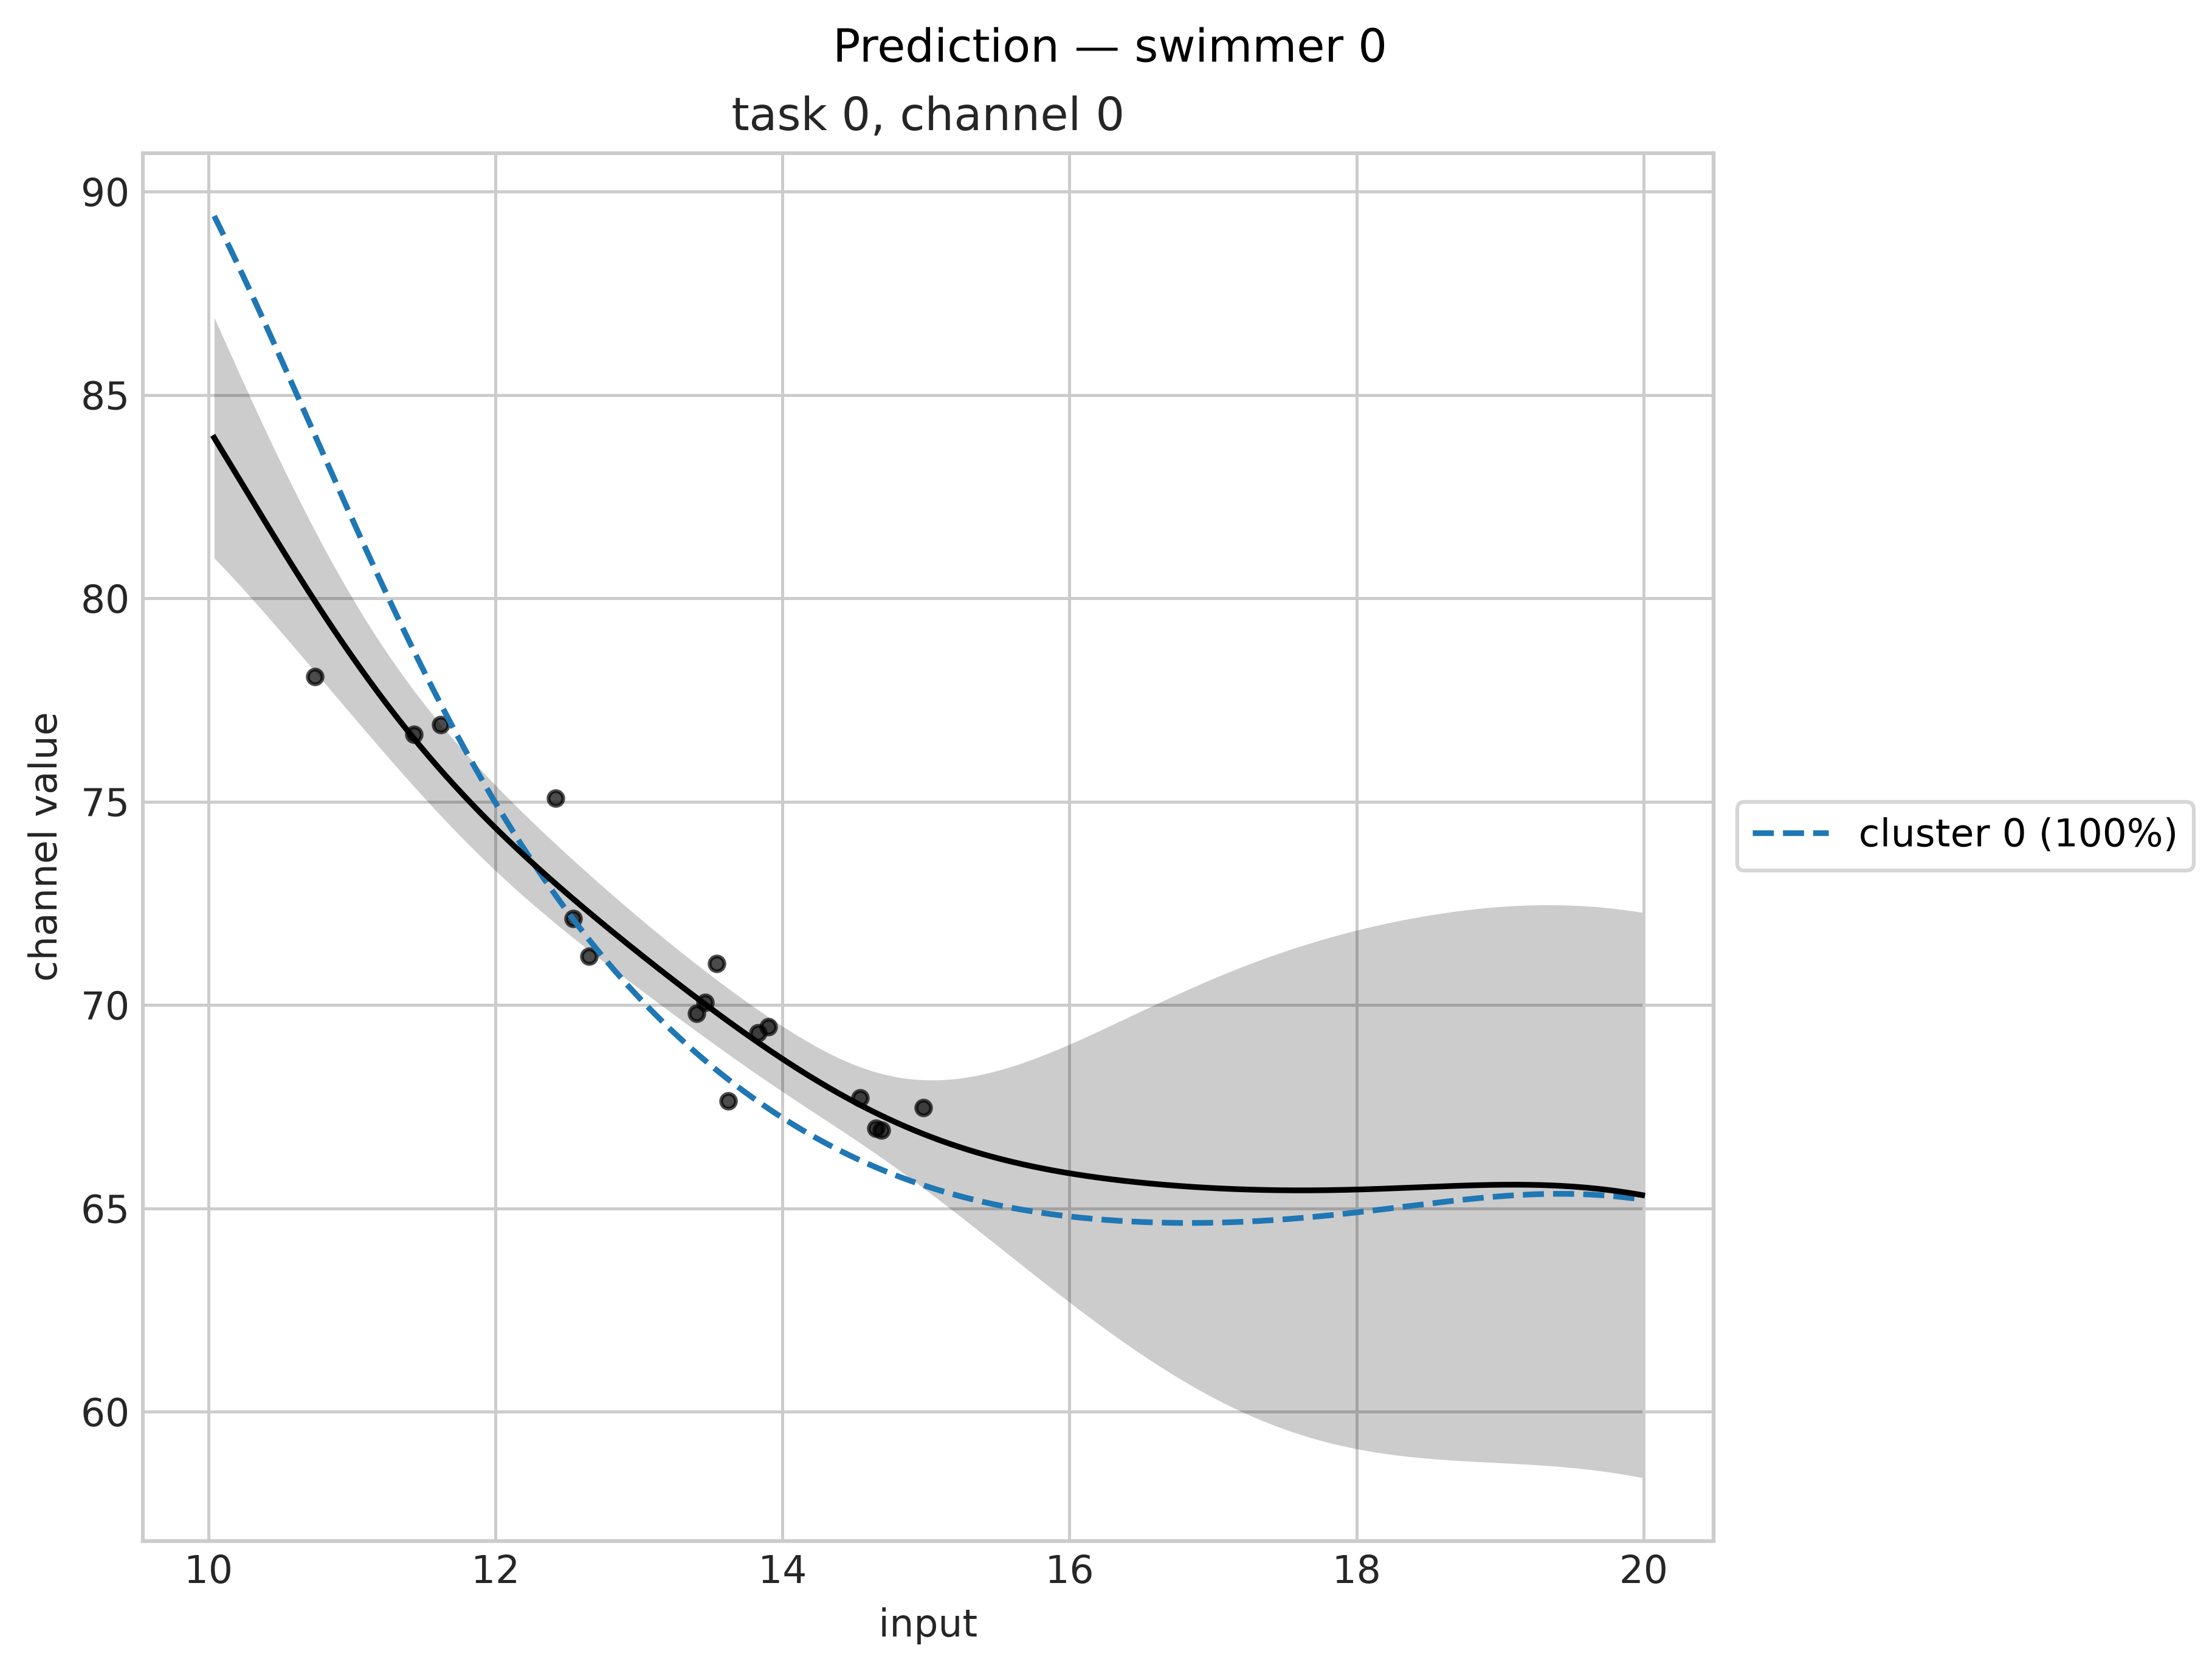

In [48]:
fig, ax = plot_single_task_prediction(
	train_data, fitted_grid, dims, hyperposterior, fitted_mixture, t_id, 0, prediction=prediction, figsize=(8 * dims.C, 6)
)
fig.suptitle(f"Prediction — swimmer {t_id}")
plt.show()

### Missing data interpolation

To go a step further, we can randomly remove half of the observed data for a test individual to evaluate interpolation performance. 